In [1]:
import logging
import time
from pathlib import Path
from typing import List, Tuple

import geopandas as gpd
import geemap.osm as gox
import pandas as pd
from tqdm import tqdm

In [2]:
def setup_logging(log_dir):
    """
    Set up logging configuration.
    
    Args:
        log_dir (str): Directory to store log files.
        
    Returns:
        Configured logger instance.
    """
    log_dir.mkdir(parents=True, exist_ok=True)
    log_file = log_dir / "0.log"
    
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)


def load_aoi_data(aoi_path, expected_crs):
    """
    Load and validate Area of Interest data.
    
    Args:
        aoi_path (str): Path to AOI file.
        expected_crs (str): Expected CRS of the input data.
        
    Returns:
        GeoDataFrame with AOI polygons
    """
    logger.info(f"Reading AOI data from {aoi_path}")
    aoi_gdf = gpd.read_parquet(aoi_path)
    
    # Ensure input data is in expected CRS
    if aoi_gdf.crs != expected_crs:
        logger.warning(f"Input data CRS {aoi_gdf.crs} doesn't match expected {expected_crs}. Converting.")
        aoi_gdf = aoi_gdf.to_crs(expected_crs)
    
    return aoi_gdf


def prepare_batch_geometry(batch_gdf, query_crs):
    """
    Prepare batch geometry for OSM query.
    
    Args:
        batch_gdf (GeoDataFrame): Batch of polygons to process.
        query_crs (str): CRS to use for OSM queries.
        
    Returns:
        Combined polygon for batch query.
    """
    # Apply small buffer to fix potential geometry issues
    buffered = batch_gdf.buffer(0.0001)
    
    # Convert to query CRS for OSM
    reprojected = buffered.to_crs(query_crs)
    
    # Combine polygons into single query geometry
    return reprojected.union_all()


def process_osm_building_data(building_gdf, output_crs):
    """
    Process and clean OSM building data.
    
    Args:
        building_gdf (GeoDataFrame): Raw building data from OSM.
        output_crs (str): CRS for output data.
        
    Returns:
        Cleaned and standardized building data.
    """
    if building_gdf.empty:
        return building_gdf
    
    # Keep essential columns and reset index
    building_clean = building_gdf.reset_index()[["id", "geometry"]]
    
    # Filter to polygons only
    building_clean = building_clean.loc[building_clean.geometry.geom_type == 'Polygon']
    
    # Reproject to output CRS
    building_clean = building_clean.to_crs(output_crs)
    
    # Standardize column names
    building_clean = building_clean.rename({"id": "osmid"}, axis=1)
    
    # Reset index for clean concatenation
    building_clean = building_clean.reset_index(drop=True)
    
    return building_clean


def remove_duplicate_buildings(building_gdf):
    """
    Remove duplicate buildings based on geometry.
    
    Args:
        building_gdf (GeoDataFrame): Building data with potential duplicates.
        
    Returns:
        Building data with duplicates removed.
    """
    if building_gdf.empty:
        return building_gdf
    
    # Create a hash of the geometry for duplicate detection
    building_gdf['geometry_hash'] = building_gdf.geometry.apply(lambda geom: geom.wkb_hex)
    
    # Remove duplicates based on geometry hash
    building_unique = building_gdf.drop_duplicates(subset=['geometry_hash'])
    
    # Drop the temporary hash column
    building_unique = building_unique.drop(columns=['geometry_hash'])
    
    return building_unique


def process_batch(batch_id, batch_polygons.GeoDataFrame, tags, 
                  query_crs, output_crs, intermediate_dir):
    """
    Process a batch of polygons to extract buildings from OSM.
    
    Args:
        batch_id (int): Identifier for the batch.
        batch_polygons (GeoDataFrame): Polygons to process in this batch.
        tags (dict): OSM tags to filter by.
        query_crs (str): CRS for OSM queries.
        output_crs (str): CRS for output data.
        intermediate_dir (str): Directory for intermediate results.
        
    Returns:
        Tuple of (building data, success flag).
    """
    intermediate_path = intermediate_dir / f"buildings_batch_{batch_id}.gzip"
    
    # Try to load existing results
    if intermediate_path.exists():
        try:
            building_data = gpd.read_parquet(intermediate_path)
            logger.info(f"Loaded existing results for batch {batch_id}")
            return building_data, True
        except Exception as e:
            logger.warning(f"Failed to load intermediate results for batch {batch_id}: {str(e)}")
    
    # Prepare geometry for OSM query
    combined_polygon = prepare_batch_geometry(batch_polygons, query_crs)
    
    # Extract buildings from OSM
    try:
        building_data = gox.osm_gdf_from_polygon(polygon=combined_polygon, tags=tags)
        
        # Process and clean the data
        building_data = process_osm_building_data(building_data, output_crs)
        
        # Save intermediate results
        building_data.to_parquet(intermediate_path, compression="gzip", index=False)
        logger.info(f"Saved intermediate results to {save_path}")
        
        return building_data, True
        
    except Exception as e:
        logger.error(f"Failed to process batch {batch_id}: {str(e)}")
        
        return gpd.GeoDataFrame(), False


def process_individual_rw(rw_id, rw_polygon.GeoDataFrame, tags, 
                          query_crs, output_crs, intermediate_dir):
    """
    Process an individual RW polygon as fallback when batch processing fails.
    
    Args:
        rw_id (int): Identifier for the RW.
        rw_polygon (GeoDataFrame): Polygon to process.
        tags (dict): OSM tags to filter by.
        query_crs (str): CRS for OSM queries.
        output_crs (str): CRS for output data.
        intermediate_dir (str): Directory for intermediate results.
        
    Returns:
        Building data for the RW.
    """
    intermediate_path = intermediate_dir / f"buildings_rw_{rw_id}.gzip"
    
    # Try to load existing results
    if intermediate_path.exists():
        try:
            building_data = load_intermediate_results(intermediate_path)
            logger.info(f"Loaded existing results for RW {rw_id}")
            return building_data
        except Exception as e:
            logger.warning(f"Failed to load intermediate results for RW {rw_id}: {str(e)}")
    
    try:
        # Prepare geometry for OSM query
        prepared_polygon = prepare_batch_geometry(rw_polygon, query_crs)
        
        # Extract buildings from OSM
        building_data = gox.osm_gdf_from_polygon(polygon=prepared_polygon, tags=tags)
        
        # Process and clean the data
        building_data = process_osm_building_data(building_data, output_crs)
        
        # Save intermediate results
        save_intermediate_results(building_data, intermediate_path)
        
        return building_data
        
    except Exception as e:
        logger.error(f"Failed to process RW {rw_id}: {str(e)}")
        return gpd.GeoDataFrame()


def save_final_results(building_gdf, output_path):
    """
    Save final building extraction results.
    
    Args:
        building_gdf (GeoDataFrame): Final building data to save.
        output_path (output_path): Path to save the data.

    Returns:
        Final building data saved.
    """
    # Create consistent unique identifier and standardize column order
    building_gdf["id"] = building_gdf.index + 1
    building_gdf = building_gdf[["id", "osmid", "geometry"]]
    
    # Save final output
    building_gdf.to_parquet(output_path, compression="gzip", index=False)
    
    print(building_gdf)
    building_gdf.plot()
    
    logger.info(f"Final output saved to {output_path}")


def clean_intermediate_files(intermediate_dir, preserve=False):
    """
    Clean up intermediate files.
    
    Args:
        intermediate_dir (str): Directory containing intermediate files
        preserve (bool, optional): Whether to preserve intermediate files
    Returns:
        Intermediate files cleaned or preserved.
    """
    if not preserve:
        logger.info("Cleaning up intermediate files")
        for file in intermediate_dir.glob("buildings_*.gzip"):
            file.unlink()
        logger.info("Intermediate files cleaned up")
    else:
        logger.info("Intermediate files preserved")

In [3]:
def main():
    """Main function to execute the building extraction pipeline."""
    # Configuration parameters
    BATCH_SIZE = 10  # Number of polygons to process in each API call
    API_DELAY = 2  # Seconds to wait between API calls to respect rate limits
    MAX_RETRIES = 3  # Maximum number of retries for failed API calls
    
    # Coordinate Reference Systems
    CRS_INPUT = "EPSG:32748"  # Jakarta is situated within UTM Zone 48S
    CRS_QUERY = "EPSG:4326"
    CRS_OUTPUT = "EPSG:32748"
    
    # File paths
    AOI_PATH = "./input/rw_jakarta.gzip"
    INTERMEDIATE_DIR = Path("./temp/0")
    OUTPUT_DIR = Path("./output/0")
    
    # Create directories if they don't exist
    INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Set up logging
    global logger
    logger = setup_logging(INTERMEDIATE_DIR)
    
    # OSM tag filter for building extraction
    building_tags = {'building': True}
    
    # Load AOI data
    aoi_gdf = load_aoi_data(AOI_PATH, CRS_INPUT)
    
    # Vectorized approach to find existing intermediate results
    existing_batches = set()
    existing_rws = set()
    
    # Find all batch files
    batch_files = list(INTERMEDIATE_DIR.glob("buildings_batch_*.gzip"))
    for file in batch_files:
        try:
            batch_num = int(file.stem.split('_')[-1])
            existing_batches.add(batch_num)
        except (ValueError, IndexError):
            continue
    
    # Find all individual RW files
    rw_files = list(INTERMEDIATE_DIR.glob("buildings_rw_*.gzip"))
    for file in rw_files:
        try:
            rw_id = int(file.stem.split('_')[-1])
            existing_rws.add(rw_id)
        except (ValueError, IndexError):
            continue
    
    logger.info(f"Found {len(existing_batches)} existing batch files and {len(existing_rws)} existing RW files")
    
    # Initialize results storage
    building_list = []  # Store results from each successful batch
    failed_batches = []  # Track failed batches for potential re-processing
    
    # Load existing batch results first
    for batch_id in sorted(existing_batches):
        try:
            intermediate_path = INTERMEDIATE_DIR / f"buildings_batch_{batch_id}.gzip"
            building_data = load_intermediate_results(intermediate_path)
            building_list.append(building_data)
            logger.info(f"Loaded existing results for batch {batch_id}")
        except Exception as e:
            logger.warning(f"Failed to load intermediate results for batch {batch_id}: {str(e)}")
    
    # Load existing individual RW results
    for rw_id in sorted(existing_rws):
        try:
            intermediate_path = INTERMEDIATE_DIR / f"buildings_rw_{rw_id}.gzip"
            building_data = load_intermediate_results(intermediate_path)
            building_list.append(building_data)
            logger.info(f"Loaded existing results for RW {rw_id}")
        except Exception as e:
            logger.warning(f"Failed to load intermediate results for RW {rw_id}: {str(e)}")
    
    # Determine which batches and RWs still need processing
    total_batches = (aoi_gdf.shape[0] + BATCH_SIZE - 1) // BATCH_SIZE
    all_batch_ids = set(range(1, total_batches + 1))
    all_rw_ids = set(range(aoi_gdf.shape[0]))
    
    batches_to_process = all_batch_ids - existing_batches
    rws_to_process = all_rw_ids - existing_rws
    
    # Remove RWs that are already covered by successfully processed batches
    for batch_id in existing_batches:
        batch_start = (batch_id - 1) * BATCH_SIZE
        batch_end = min(batch_start + BATCH_SIZE, aoi_gdf.shape[0])
        batch_rw_ids = set(range(batch_start, batch_end))
        rws_to_process -= batch_rw_ids
    
    logger.info(f"Need to process {len(batches_to_process)} batches and {len(rws_to_process)} individual RWs")
    
    # Process remaining batches
    with tqdm(total=len(batches_to_process) * BATCH_SIZE + len(rws_to_process), 
              desc="Querying remaining buildings") as pbar:
        
        # Process batches that haven't been completed yet
        for batch_id in sorted(batches_to_process):
            batch_start = (batch_id - 1) * BATCH_SIZE
            batch_end = min(batch_start + BATCH_SIZE, aoi_gdf.shape[0])
            
            # Get batch polygons
            batch_polygons = aoi_gdf.iloc[batch_start:batch_end]
            
            # Process batch with retries
            success = False
            for attempt in range(MAX_RETRIES):
                building_data, success = process_batch(
                    batch_id, batch_polygons, building_tags, 
                    CRS_QUERY, CRS_OUTPUT, INTERMEDIATE_DIR
                )
                
                if success:
                    building_list.append(building_data)
                    pbar.set_description(f"Processed batch {batch_id}/{total_batches}")
                    pbar.update(batch_end - batch_start)
                    break  # Exit retry loop on success
                else:
                    logger.warning(f"Attempt {attempt+1} failed for batch {batch_id}")
                    if attempt < MAX_RETRIES - 1:
                        time.sleep(API_DELAY * 2)  # Longer delay before retry
            
            if not success:
                # Mark batch as failed and add its RWs to the individual processing list
                failed_batches.append(batch_id)
                batch_rw_ids = set(range(batch_start, batch_end))
                rws_to_process.update(batch_rw_ids)
                pbar.update(batch_end - batch_start)
            
            # Respect OSM API rate limits with delay between requests
            time.sleep(API_DELAY)
        
        # Process individual RWs that still need processing
        for rw_id in sorted(rws_to_process):
            rw_polygon = aoi_gdf.iloc[rw_id:rw_id+1]  # Get single row as DataFrame
            
            building_data = process_individual_rw(
                rw_id, rw_polygon, building_tags,
                CRS_QUERY, CRS_OUTPUT, INTERMEDIATE_DIR
            )
            
            if not building_data.empty:
                building_list.append(building_data)
            
            pbar.update(1)
            time.sleep(API_DELAY)  # Respect rate limits
    
    # Combine all successful results
    if building_list:
        building_final = pd.concat(building_list, ignore_index=True)
        
        # Final duplicate removal across all batches
        if not building_final.empty:
            logger.info(f"Before final duplicate removal: {len(building_final)} buildings")
            building_final = remove_duplicate_buildings(building_final)
            logger.info(f"After final duplicate removal: {len(building_final)} unique buildings")
        
        # Save final results
        output_path = OUTPUT_DIR / "buildings.gzip"
        save_final_results(building_final, output_path)
        logger.info(f"Successfully processed {len(building_final)} unique buildings")
        
        # Clean up intermediate files if processing completed successfully
        clean_intermediate_files(INTERMEDIATE_DIR, preserve=bool(failed_batches))
        
        if failed_batches:
            logger.warning(f"Failed to process the following batches: {failed_batches}")
        
        return building_final
    else:
        logger.error("No buildings were successfully processed")
        return gpd.GeoDataFrame()

2025-10-27 15:13:02,760 - INFO - Reading AOI data from ./input/rw_jakarta.gzip
2025-10-27 15:13:13,348 - INFO - Found 274 existing batch files and 20 existing RW files
2025-10-27 15:13:13,371 - INFO - Loaded existing results for batch 1
2025-10-27 15:13:13,393 - INFO - Loaded existing results for batch 2
2025-10-27 15:13:13,410 - INFO - Loaded existing results for batch 3
2025-10-27 15:13:13,427 - INFO - Loaded existing results for batch 4
2025-10-27 15:13:13,442 - INFO - Loaded existing results for batch 5
2025-10-27 15:13:13,458 - INFO - Loaded existing results for batch 6
2025-10-27 15:13:13,474 - INFO - Loaded existing results for batch 7
2025-10-27 15:13:13,491 - INFO - Loaded existing results for batch 8
2025-10-27 15:13:13,510 - INFO - Loaded existing results for batch 9
2025-10-27 15:13:13,527 - INFO - Loaded existing results for batch 10
2025-10-27 15:13:13,543 - INFO - Loaded existing results for batch 11
2025-10-27 15:13:13,560 - INFO - Loaded existing results for batch 12
2

              id      osmid                                           geometry
0              1  122159883  POLYGON ((698786.928 9321438.503, 698796.371 9...
1              2  122159942  POLYGON ((698740.627 9321429.645, 698773.882 9...
2              3  122160017  POLYGON ((698736.006 9321500.83, 698767.366 93...
3              4  129174897  POLYGON ((693758.875 9323938.162, 693715.916 9...
4              5  129174898  POLYGON ((693177.249 9323966.827, 693183.435 9...
...          ...        ...                                                ...
1670715  1670716  506381536  POLYGON ((700473.038 9315981.66, 700480.448 93...
1670716  1670717  508594320  POLYGON ((700450.147 9316004.068, 700456.023 9...
1670717  1670718  508594322  POLYGON ((700450.089 9316009.819, 700455.578 9...
1670718  1670719  508594325  POLYGON ((700433.279 9315955.617, 700445.247 9...
1670719  1670720  636067313  POLYGON ((700388.79 9315948.17, 700393.226 931...

[1656106 rows x 3 columns]


2025-10-27 15:17:06,680 - INFO - Final output saved to output/0/buildings.gzip
2025-10-27 15:17:06,683 - INFO - Successfully processed 1656106 unique buildings
2025-10-27 15:17:06,683 - INFO - Intermediate files preserved
2025-10-27 15:17:06,684 - WARNING - Failed to process the following batches: [263, 271]


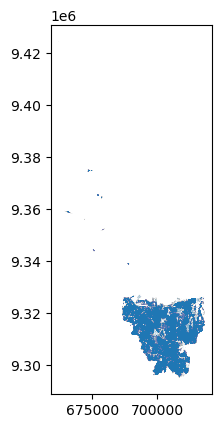

In [4]:
if __name__ == "__main__":
    result = main()